# LAB | Feature Engineering

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [5]:
shape = spaceship.shape
print("Shape:", spaceship.shape)

Shape: (8693, 14)


**Check for data types**

In [7]:
spaceship.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

**Check for missing values**

In [8]:
spaceship.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value. 

In [10]:
#drop rows containing any missing value
spaceship_clean = spaceship.dropna()
# check the new shape
print(f"Original shape: {spaceship.shape}")
print(f"New shape: {spaceship_clean.shape}")
# Confirm there is any nule value
print(f"Total nule values: {spaceship_clean.isnull().sum().sum()}")

Original shape: (8693, 14)
New shape: (6606, 14)
Total nule values: 0


- **Cabin** is too granular - transform it in order to obtain {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'}

In [14]:
spaceship_clean.loc[:, 'Cabin'] = spaceship_clean['Cabin'].astype(str).str[0]
print(spaceship_clean['Cabin'].unique())
print(spaceship_clean['Cabin'].value_counts().sort_index())

['B' 'F' 'A' 'G' 'E' 'C' 'D' 'T']
Cabin
A     207
B     628
C     587
D     374
E     683
F    2152
G    1973
T       2
Name: count, dtype: int64


- Drop PassengerId and Name

In [15]:
spaceship_clean = spaceship_clean.drop(['PassengerId', 'Name'], axis=1)
print(spaceship_clean.columns)
print(f"New shape: {spaceship_clean.shape}")

Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported'],
      dtype='object')
New shape: (6606, 12)


- For non-numerical columns, do dummies.

In [16]:
spaceship_final = pd.get_dummies(spaceship_clean, drop_first=True)
print(f"Number rows before: {spaceship_clean.shape[1]}")
print(f"Number rows now: {spaceship_final.shape[1]}")
print(" ")
print(spaceship_final.head())

Number rows before: 12
Number rows now: 20
 
    Age  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  Transported  \
0  39.0          0.0        0.0           0.0     0.0     0.0        False   
1  24.0        109.0        9.0          25.0   549.0    44.0         True   
2  58.0         43.0     3576.0           0.0  6715.0    49.0        False   
3  33.0          0.0     1283.0         371.0  3329.0   193.0        False   
4  16.0        303.0       70.0         151.0   565.0     2.0         True   

   HomePlanet_Europa  HomePlanet_Mars  CryoSleep_True  Cabin_B  Cabin_C  \
0               True            False           False     True    False   
1              False            False           False    False    False   
2               True            False           False    False    False   
3               True            False           False    False    False   
4              False            False           False    False    False   

   Cabin_D  Cabin_E  Cabin_F  Cabin

**Perform Train Test Split**

In [20]:
y = spaceship_final['Transported']
X = spaceship_final.drop('Transported', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total: {len(spaceship_final)}")
print(f" (X_train): {len(X_train)}")
print(f" (X_test): {len(X_test)}")

Total: 6606
 (X_train): 5284
 (X_test): 1322


**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7874


- Evaluate your model's performance. Comment it

Classification Report:
              precision    recall  f1-score   support

       False       0.78      0.79      0.79       653
        True       0.79      0.78      0.79       669

    accuracy                           0.79      1322
   macro avg       0.79      0.79      0.79      1322
weighted avg       0.79      0.79      0.79      1322



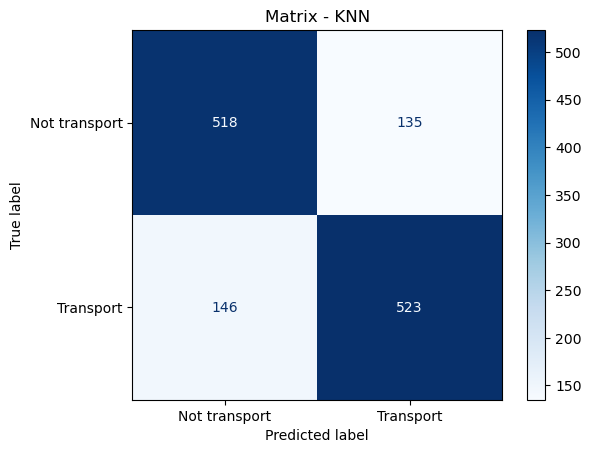

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Clasiffication report
print("Classification Report:")
print(classification_report(y_test, y_pred))

#Display the matix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not transport', 'Transport'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrix - KNN")
plt.show()